Merged Dataset Shape : (1017209, 18)
Dataset Shape: (1017209, 18)

Data Types:

store                          int64
dayofweek                      int64
date                          object
sales                          int64
customers                      int64
open                           int64
promo                          int64
stateholiday                  object
schoolholiday                  int64
storetype                     object
assortment                    object
competitiondistance          float64
competitionopensincemonth    float64
competitionopensinceyear     float64
promo2                         int64
promo2sinceweek              float64
promo2sinceyear              float64
promointerval                 object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    ----

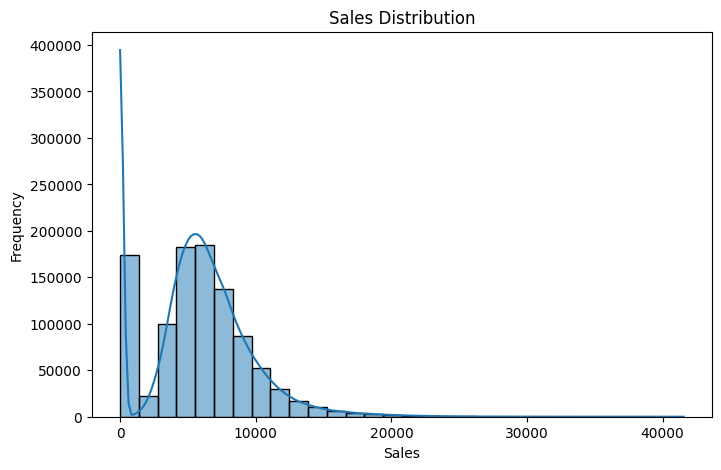

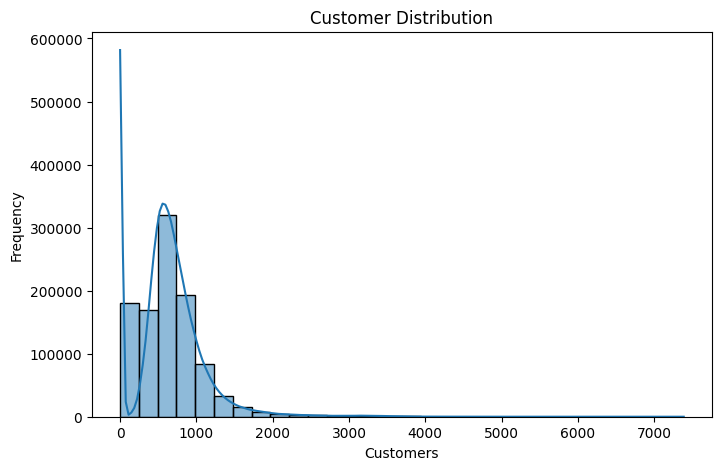

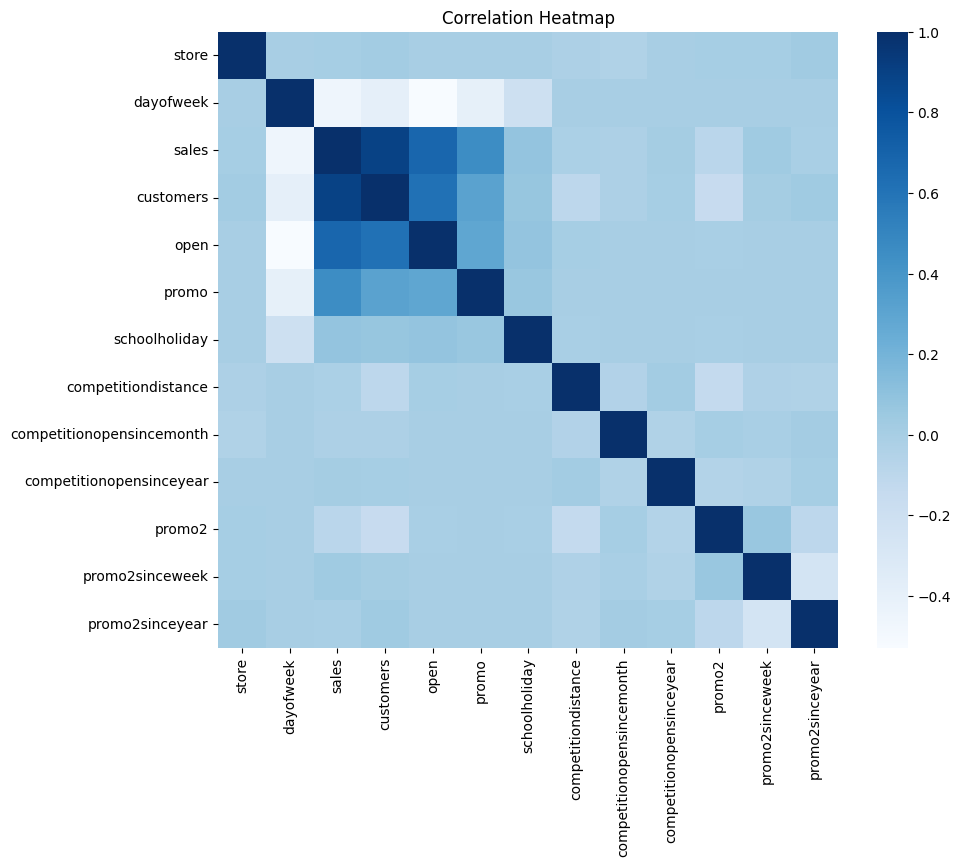


Feature Engineering Completed!
   store  dayofweek       date  sales  customers  open  promo stateholiday  \
0      1          4 2015-07-31   5263        555     1      1            0   
1      2          4 2015-07-31   6064        625     1      1            0   
2      3          4 2015-07-31   8314        821     1      1            0   
3      4          4 2015-07-31  13995       1498     1      1            0   
4      5          4 2015-07-31   4822        559     1      1            0   

   schoolholiday storetype  ... promo2  promo2sinceweek  promo2sinceyear  \
0              1         c  ...      0             22.0           2012.0   
1              1         a  ...      1             13.0           2010.0   
2              1         a  ...      1             14.0           2011.0   
3              1         c  ...      0             22.0           2012.0   
4              1         a  ...      0             22.0           2012.0   

     promointerval  year  month  day week 

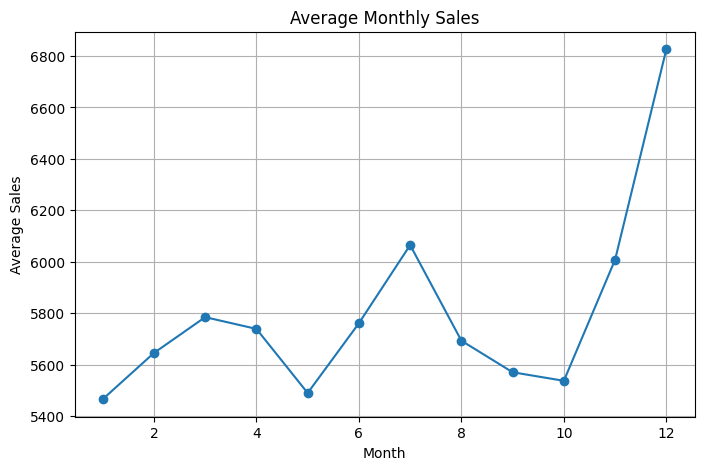

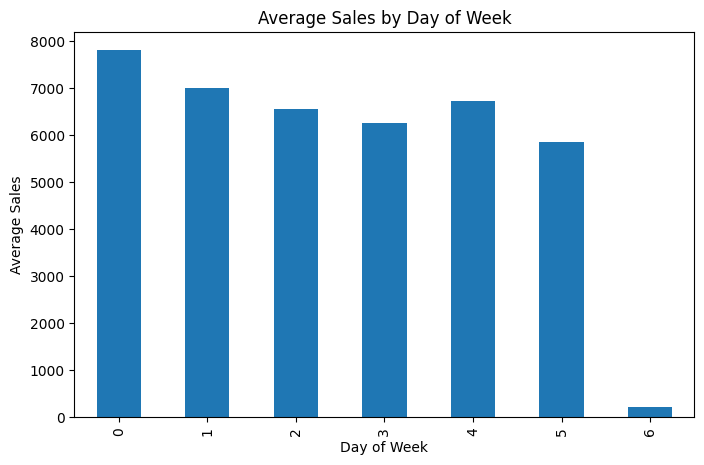

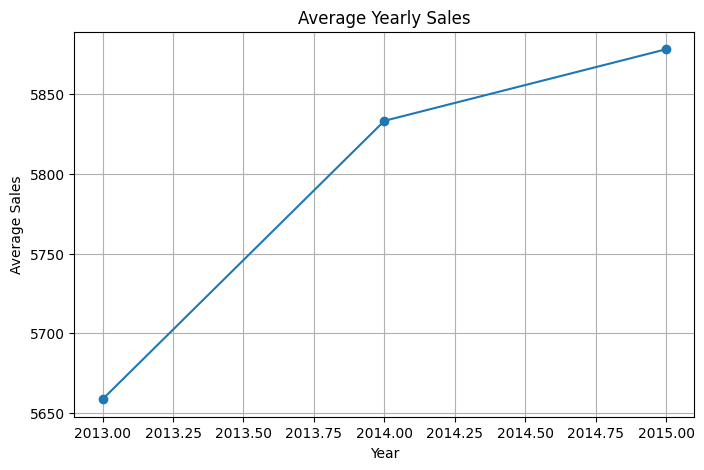

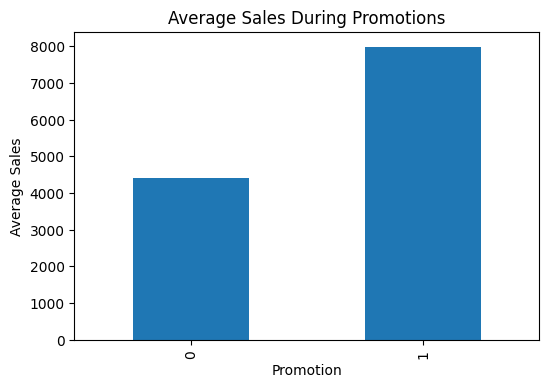

Cleaned data saved as 'retail_demand_cleaned.csv'
Feature Matrix Shape : (1017209, 22)
Target Shape : (1017209,)
Training Data Shape : (813767, 22)
Testing Data Shape  : (203442, 22)
Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.

Model Performance

                          MAE         RMSE  R2 Score
Linear Regression  940.244685  1392.383595  0.868905
Decision Tree      375.221857   628.047636  0.973328
Random Forest      271.321146   453.039531  0.986122

Best Model : Random Forest

Model saved successfully as 'retail_demand_model.pkl'

Sample Predictions:

   Predicted Sales
0             0.00
1          5734.95
2          7700.50
3          3604.20
4          9239.15


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import pickle

warnings.filterwarnings("ignore")
#  LOAD DATA

def load_data(train_path, store_path):

    train_df = pd.read_csv(train_path)
    store_df = pd.read_csv(store_path)

    # Standardize column names
    train_df.columns = (
        train_df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )

    store_df.columns = (
        store_df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )

    return train_df, store_df


# MERGE DATA
def merge_data(train_df, store_df):

    df = pd.merge(
        train_df,
        store_df,
        on="store",
        how="left"
    )

    print("Merged Dataset Shape :", df.shape)

    return df

def basic_info(df):

    print("Dataset Shape:", df.shape)

    print("\nData Types:\n")
    print(df.dtypes)

    print("\nDataset Info:")
    df.info()

    print("\nMissing Values:\n")
    print(df.isnull().sum())

    print("\n--- CATEGORICAL UNIQUE VALUES ---")
    for col in df.select_dtypes(include=['object', 'category']).columns:
        print(f"{col}: {df[col].nunique()} unique values")


def clean_data(df):

    # Clean column names
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )

    # Convert date column to datetime
    # Use errors='coerce' to turn unparseable dates into NaT
    df["date"] = pd.to_datetime(df["date"], errors='coerce')

    # Drop rows where 'date' is NaT (missing or invalid date)
    initial_rows = len(df)
    df.dropna(subset=['date'], inplace=True)
    rows_dropped = initial_rows - len(df)
    if rows_dropped > 0:
        print(f"Dropped {rows_dropped} rows with missing or invalid 'date' values.")

    # Check duplicates
    duplicate_count = df.duplicated().sum()
    print("Duplicate Rows: ", duplicate_count)

    df = df.drop_duplicates()

    return df

#  HANDLE MISSING VALUES

def handle_missing_values(df):

    # Fill missing values in numerical columns with median
    numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())

    # Fill missing values in categorical columns with mode
    categorical_cols = df.select_dtypes(include=["object"]).columns

    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    print("\nMissing Values After Handling:\n")
    print(df.isnull().sum())

    return df

# EXPLORATORY DATA ANALYSIS

def perform_eda(df):

    plt.figure(figsize=(8,5))
    sns.histplot(df["sales"], bins=30, kde=True)
    plt.title("Sales Distribution")
    plt.xlabel("Sales")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(df["customers"], bins=30, kde=True)
    plt.title("Customer Distribution")
    plt.xlabel("Customers")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="Blues")
    plt.title("Correlation Heatmap")
    plt.show()

#FEATURE ENGINEERING

def feature_engineering(df):

    # Convert date column to datetime (safe check)
    # This is already done and NaT handled in clean_data, but good for robustness
    df["date"] = pd.to_datetime(df["date"], errors='coerce')
    df.dropna(subset=['date'], inplace=True)

    # Date-based features
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["week"] = df["date"].dt.isocalendar().week.astype(int)
    df["dayofweek"] = df["date"].dt.dayofweek
    df["quarter"] = df["date"].dt.quarter

    # Weekend flag
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    print("\nFeature Engineering Completed!")
    print(df.head())

    return df


#  TREND & SEASONAL ANALYSIS
def trend_analysis(df):

    # Monthly Sales Trend
    monthly_sales = df.groupby("month")["sales"].mean()

    plt.figure(figsize=(8,5))
    monthly_sales.plot(marker="o")
    plt.title("Average Monthly Sales")
    plt.xlabel("Month")
    plt.ylabel("Average Sales")
    plt.grid(True)
    plt.show()


    # Weekly Sales Trend
    weekly_sales = df.groupby("dayofweek")["sales"].mean()

    plt.figure(figsize=(8,5))
    weekly_sales.plot(kind="bar")
    plt.title("Average Sales by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("Average Sales")
    plt.show()


    # Yearly Sales Trend
    yearly_sales = df.groupby("year")["sales"].mean()

    plt.figure(figsize=(8,5))
    yearly_sales.plot(marker="o")
    plt.title("Average Yearly Sales")
    plt.xlabel("Year")
    plt.ylabel("Average Sales")
    plt.grid(True)
    plt.show()


    # Promotion Analysis
    promo_sales = df.groupby("promo")["sales"].mean()

    plt.figure(figsize=(6,4))
    promo_sales.plot(kind="bar")
    plt.title("Average Sales During Promotions")
    plt.xlabel("Promotion")
    plt.ylabel("Average Sales")
    plt.show()

def save_cleaned_data(df):

    df.to_csv(
        "retail_demand_cleaned.csv",
        index=False
    )

    print("Cleaned data saved as 'retail_demand_cleaned.csv'")


#  PREPARE FEATURES & TARGET
def prepare_model_data(df):

    # Target variable
    y = df["sales"]

    # Features
    X = df.drop(columns=["sales", "date"])

    # Encode categorical columns
    categorical_cols = X.select_dtypes(include=["object"]).columns

    encoder = LabelEncoder()

    for col in categorical_cols:
        X[col] = encoder.fit_transform(X[col].astype(str))

    print("Feature Matrix Shape :", X.shape)
    print("Target Shape :", y.shape)

    return X, y

# TRAIN TEST SPLIT

def split_data(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print("Training Data Shape :", X_train.shape)
    print("Testing Data Shape  :", X_test.shape)

    return X_train, X_test, y_train, y_test


#  TRAIN MODELS

def train_models(X_train, y_train):

    models = {

        "Linear Regression": LinearRegression(),

        "Decision Tree": DecisionTreeRegressor(random_state=42),

        "Random Forest": RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
     )
    }


    trained_models = {}

    for model_name, model in models.items():

        model.fit(X_train, y_train)

        trained_models[model_name] = model

        print(f"{model_name} trained successfully.")

    return trained_models


  # =========================
# 12. EVALUATE MODELS
# =========================

def evaluate_models(models, X_test, y_test):

    results = {}

    for model_name, model in models.items():

        predictions = model.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        r2 = r2_score(y_test, predictions)

        results[model_name] = {
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        }

    results_df = pd.DataFrame(results).T

    print("\nModel Performance\n")
    print(results_df)

    best_model = results_df["R2 Score"].idxmax()

    print(f"\nBest Model : {best_model}")

    return models[best_model]

# SAVE BEST MODEL

def save_model(model, filename):

    with open(filename, "wb") as file:
        pickle.dump(model, file)

    print(f"\nModel saved successfully as '{filename}'")


# PREDICT DEMAND
def predict_demand(model, X_test):

    predictions = model.predict(X_test)

    prediction_df = pd.DataFrame({
        "Predicted Sales": predictions
    })

    print("\nSample Predictions:\n")
    print(prediction_df.head())

    return prediction_df

#  MAIN PIPELINE

def main_pipeline(train_path, store_path):

    # Load Data
    train_df, store_df = load_data(train_path, store_path)

    # Merge Data
    df = merge_data(train_df, store_df)

    # Basic Information
    basic_info(df)

    # Clean Data
    df = clean_data(df)

     # Handle Missing Values
    df = handle_missing_values(df)

    perform_eda(df)

    # Feature Engineering
    df = feature_engineering(df)

     # Trend Analysis
    trend_analysis(df)

     # Save Cleaned Data
    save_cleaned_data(df)


    # Prepare Features & Target
    X, y = prepare_model_data(df)

    # Train-Test Split
    X_train, X_test, y_train, y_test = split_data(X, y)

    trained_models = train_models(X_train, y_train)

    best_model = evaluate_models(
        trained_models,
        X_test,
        y_test
    )


    # Save Best Model
    save_model(best_model, "retail_demand_model.pkl")

    # Predict Demand
    prediction_df = predict_demand(best_model, X_test)




main_pipeline(
    train_path="/content/train.csv",
    store_path="/content/store.csv"
)